# Detecting Illicit Bitcoin Transactions with Graph Convolutional Networks (GCN)

This notebook implements a baseline **Graph Convolutional Network (GCN)** on the Elliptic Bitcoin dataset. Unlike standard tabular models (like Random Forests) that only look at individual transaction features, GCNs leverage the network topology—who is sending money to whom.

### The Math Behind GCNs
At its core, a GCN updates the features of a node by aggregating the features of its direct neighbors. The layer-wise propagation rule is defined mathematically as:

$$H^{(l+1)} = \sigma\left(\tilde{D}^{-\frac{1}{2}}\tilde{A}\tilde{D}^{-\frac{1}{2}}H^{(l)}W^{(l)}\right)$$

* $H^{(l)}$: The matrix of node features at layer $l$.
* $\tilde{A}$: The adjacency matrix of the graph with added self-connections (so a node doesn't forget its own features).
* $\tilde{D}$: The degree matrix, used to mathematically normalize the connections so nodes with millions of transactions don't overpower the network.
* $W^{(l)}$: The trainable weight matrix for the current layer.
* $\sigma$: The activation function (like ReLU).

By passing data through multiple layers, the network learns to identify "guilt by association" and flags normal-looking transactions that are connected to illicit networks.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from torch import Tensor, nn
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from torch_geometric.utils import to_undirected

# Configuration (Replaces argparse)
CONFIG = {
    "epochs": 100,
    "hidden_channels": 64,
    "dropout": 0.3,
    "lr": 1e-3,
    "weight_decay": 5e-4,
    "train_size": 0.7,
    "val_size": 0.15,
    "seed": 42,
    "directed": False
}

PROJECT_ROOT = Path().resolve().parent
DEFAULT_DATA_DIR = PROJECT_ROOT / "data" / "raw" / "elliptic_bitcoin_data" / "elliptic_bitcoin_dataset"

LABEL_MAP = {"2": 0, "1": 1, "licit": 0, "illicit": 1, "unknown": -1}

@dataclass
class DatasetBundle:
    data: Data
    tx_ids: pd.Series
    known_mask: np.ndarray

class FraudGCN(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int, dropout: float) -> None:
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.classifier = nn.Linear(hidden_channels, 2)
        self.dropout = dropout

    def forward(self, x: Tensor, edge_index: Tensor, return_embeds: bool = False) -> Tensor:
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        
        if return_embeds:
            return x # Return raw embeddings for t-SNE visualization
            
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.classifier(x)

In [3]:
def load_elliptic_dataset(data_dir: Path, make_undirected: bool = True) -> DatasetBundle:
    features_path = data_dir / "elliptic_txs_features.csv"
    edges_path = data_dir / "elliptic_txs_edgelist.csv"
    labels_path = data_dir / "elliptic_txs_classes.csv"

    features_df = pd.read_csv(features_path, header=None)
    edges_df = pd.read_csv(edges_path)
    labels_df = pd.read_csv(labels_path)

    tx_ids = features_df.iloc[:, 0].astype(np.int64)
    id_to_idx = {tx_id: idx for idx, tx_id in enumerate(tx_ids.tolist())}

    x = torch.tensor(features_df.iloc[:, 1:].to_numpy(dtype=np.float32), dtype=torch.float32)

    label_series = labels_df.set_index("txId")["class"].astype(str).map(LABEL_MAP)
    y_np = tx_ids.map(label_series).fillna(-1).astype(np.int64).to_numpy()
    y = torch.tensor(y_np, dtype=torch.long)

    src = edges_df["txId1"].map(id_to_idx)
    dst = edges_df["txId2"].map(id_to_idx)
    valid_edges = src.notna() & dst.notna()
    edge_index = torch.tensor(
        np.vstack([src[valid_edges].to_numpy(dtype=np.int64), dst[valid_edges].to_numpy(dtype=np.int64)]),
        dtype=torch.long,
    )

    if make_undirected:
        edge_index = to_undirected(edge_index)

    known_mask = y_np >= 0
    data = Data(x=x, edge_index=edge_index, y=y)
    return DatasetBundle(data=data, tx_ids=tx_ids, known_mask=known_mask)

def build_masks(labels: np.ndarray, known_mask: np.ndarray, train_size: float, val_size: float, seed: int):
    known_indices = np.where(known_mask)[0]
    known_labels = labels[known_indices]

    train_idx, held_out_idx = train_test_split(known_indices, train_size=train_size, random_state=seed, stratify=known_labels)
    held_out_labels = labels[held_out_idx]
    relative_val_size = val_size / (1.0 - train_size)
    val_idx, test_idx = train_test_split(held_out_idx, train_size=relative_val_size, random_state=seed, stratify=held_out_labels)

    train_mask = torch.zeros(labels.shape[0], dtype=torch.bool)
    val_mask = torch.zeros(labels.shape[0], dtype=torch.bool)
    test_mask = torch.zeros(labels.shape[0], dtype=torch.bool)

    train_mask[train_idx] = True
    val_mask[val_idx] = True
    test_mask[test_idx] = True

    return train_mask, val_mask, test_mask

In [4]:
def evaluate(model: nn.Module, data: Data, mask: Tensor) -> dict[str, float]:
    model.eval()
    with torch.no_grad():
        logits = model(data.x, data.edge_index)
        preds = logits[mask].argmax(dim=1).cpu().numpy()
        targets = data.y[mask].cpu().numpy()

    return {
        "f1": f1_score(targets, preds, zero_division=0),
        "precision": precision_score(targets, preds, zero_division=0),
        "recall": recall_score(targets, preds, zero_division=0),
    }

def train_model(data: Data, config: dict, device: torch.device):
    model = FraudGCN(data.num_node_features, config["hidden_channels"], config["dropout"]).to(device)
    data = data.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
    
    train_targets = data.y[data.train_mask]
    class_counts = torch.bincount(train_targets, minlength=2).clamp_min(1).float()
    class_weights = (class_counts.sum() / (2.0 * class_counts)).to(device)

    best_state, best_val_f1 = None, -1.0
    
    # Tracking for visualizations
    history = {"train_loss": [], "val_f1": []}

    for epoch in range(1, config["epochs"] + 1):
        model.train()
        optimizer.zero_grad()
        logits = model(data.x, data.edge_index)
        loss = F.cross_entropy(logits[data.train_mask], data.y[data.train_mask], weight=class_weights)
        loss.backward()
        optimizer.step()

        val_metrics = evaluate(model, data, data.val_mask)
        history["train_loss"].append(loss.item())
        history["val_f1"].append(val_metrics["f1"])

        if val_metrics["f1"] > best_val_f1:
            best_val_f1 = val_metrics["f1"]
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}

        if epoch % 20 == 0:
            print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f} | Val F1: {val_metrics['f1']:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

Loading Graph Data...
Training GCN on cpu...
Epoch 020 | Loss: 0.5102 | Val F1: 0.4227
Epoch 040 | Loss: 0.3948 | Val F1: 0.4621
Epoch 060 | Loss: 0.3387 | Val F1: 0.5222
Epoch 080 | Loss: 0.3025 | Val F1: 0.5750
Epoch 100 | Loss: 0.2742 | Val F1: 0.6111

--- Final Test Report ---
Test F1: 0.6341 | Precision: 0.4971 | Recall: 0.8754


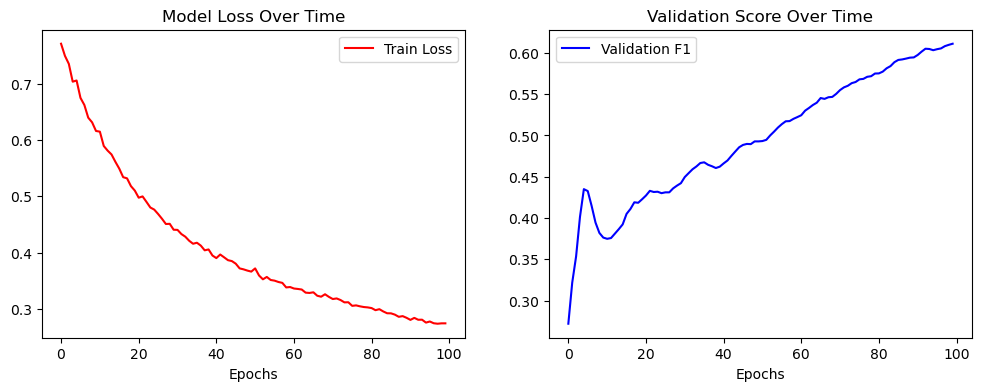

Generating t-SNE plot (this takes a moment)...


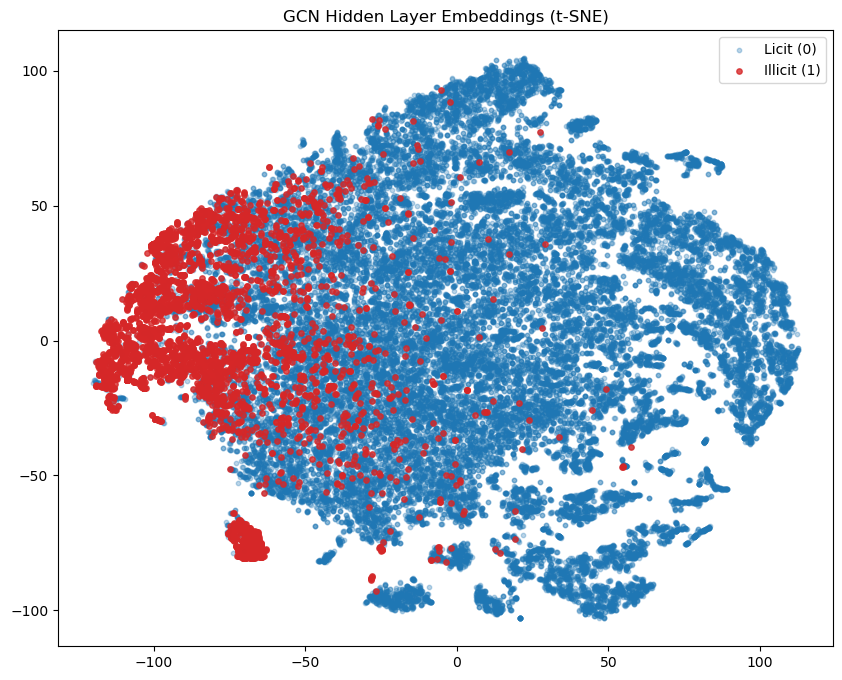

In [5]:
# 1. Initialize and Load Data
torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Loading Graph Data...")
bundle = load_elliptic_dataset(DEFAULT_DATA_DIR, make_undirected=not CONFIG["directed"])
train_mask, val_mask, test_mask = build_masks(bundle.data.y.cpu().numpy(), bundle.known_mask, CONFIG["train_size"], CONFIG["val_size"], CONFIG["seed"])
bundle.data.train_mask, bundle.data.val_mask, bundle.data.test_mask = train_mask, val_mask, test_mask

# 2. Train the Model
print(f"Training GCN on {device}...")
model, history = train_model(bundle.data, CONFIG, device)
bundle.data = bundle.data.to(device)

# 3. Final Evaluation
print("\n--- Final Test Report ---")
test_metrics = evaluate(model, bundle.data, bundle.data.test_mask)
print(f"Test F1: {test_metrics['f1']:.4f} | Precision: {test_metrics['precision']:.4f} | Recall: {test_metrics['recall']:.4f}")

# --- VISUALIZATION 1: Training Curves ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss", color="red")
plt.title("Model Loss Over Time")
plt.xlabel("Epochs")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["val_f1"], label="Validation F1", color="blue")
plt.title("Validation Score Over Time")
plt.xlabel("Epochs")
plt.legend()
plt.show()

# --- VISUALIZATION 2: t-SNE Embeddings ---
print("Generating t-SNE plot (this takes a moment)...")
model.eval()
with torch.no_grad():
    embeds = model(bundle.data.x, bundle.data.edge_index, return_embeds=True).cpu().numpy()

known_mask = (bundle.data.y.cpu().numpy() >= 0)
labels = bundle.data.y.cpu().numpy()[known_mask]
embeds_known = embeds[known_mask]


tsne = TSNE(n_components=2, random_state=42)
embeds_2d = tsne.fit_transform(embeds_known)

plt.figure(figsize=(10, 8))
plt.scatter(embeds_2d[labels == 0, 0], embeds_2d[labels == 0, 1], c='#1f77b4', label='Licit (0)', alpha=0.3, s=10)
plt.scatter(embeds_2d[labels == 1, 0], embeds_2d[labels == 1, 1], c='#d62728', label='Illicit (1)', alpha=0.8, s=15)
plt.title("GCN Hidden Layer Embeddings (t-SNE)")
plt.legend()
plt.show()